In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")

import jaxsp as jsp

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt

from jaxsp.constants import GN, hbar

import matplotlib.pyplot as plt

from collections import defaultdict



m22 = 1
u = jsp.set_schroedinger_units(m22)


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [2]:



cNFWtides_params = jnp.array([
357964808.148399 * u.from_Msun,
25.690207,
0.407461,
0.012670 * u.from_Kpc,
1.857991 * u.from_Kpc,
3.729259
])

density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

N = 512
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

N = 1024
a = 1
b = 10

rmax = jsp.enclosing_radius(0.99, density_params)
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)


eigen_energies = eigenstate_lib.radial_eigenmode_params.E

l = eigenstate_lib.radial_eigenmode_params.l

n = eigenstate_lib.radial_eigenmode_params.n

rmin = 20 * u.from_pc

tol = 1e-7
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)

aj_2 = wavefunction_params.aj_2 



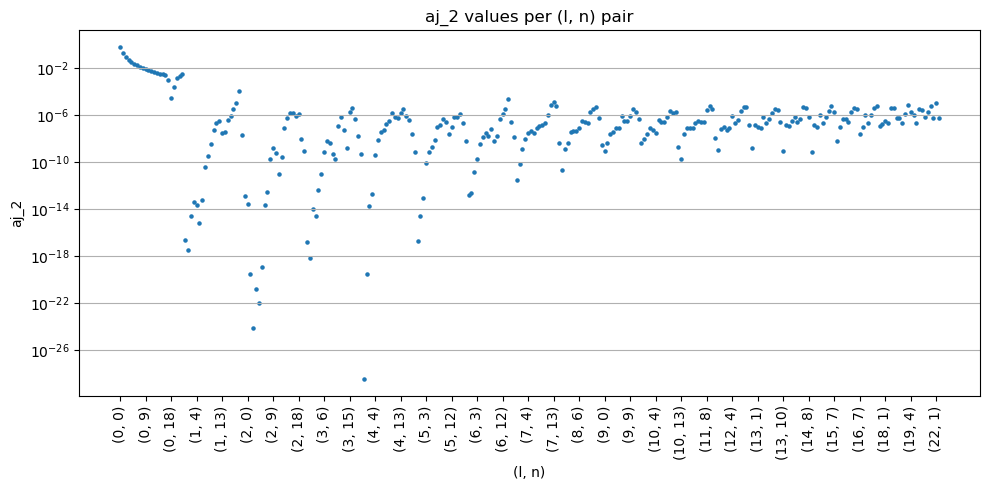

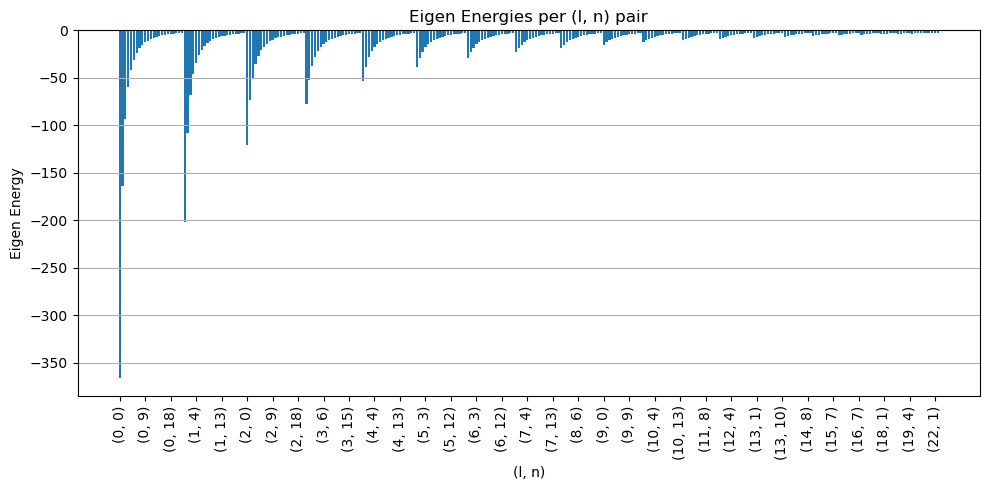

smallest time period [Gyr]: 0.06288193678396325


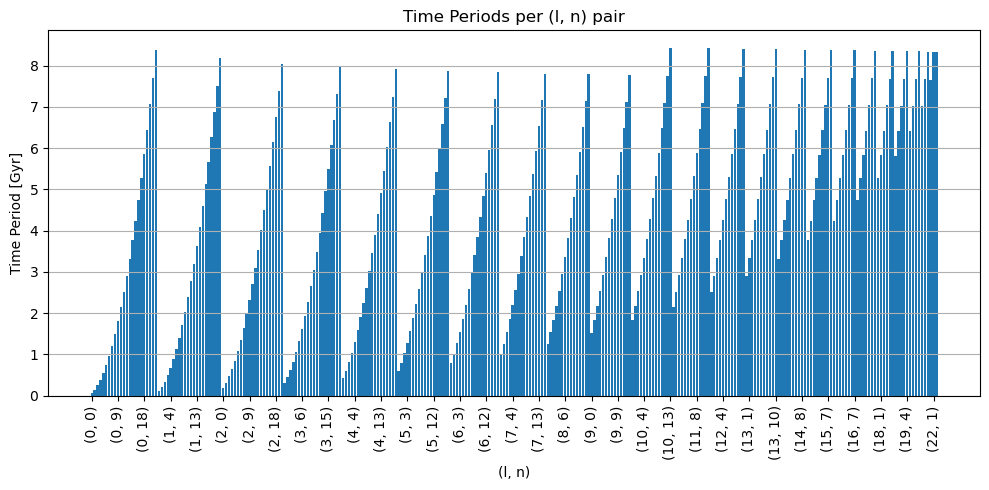

In [3]:

nl_labels = list(zip(l.tolist(), n.tolist()))


plt.figure(figsize=(10, 5))
plt.scatter(range(len(aj_2)), aj_2, s=5)

step = max(1, len(nl_labels) // 30)  # show ~30 labels
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('aj_2')
plt.title('aj_2 values per (l, n) pair')
plt.grid(axis='y')
plt.yscale('log')
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.bar(range(len(eigen_energies)), eigen_energies)

step = max(1, len(nl_labels) // 30)
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Eigen Energy')
plt.title('Eigen Energies per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

time_periods = -(1 / eigen_energies) * u.to_Gyr

print('smallest time period [Gyr]:', time_periods.min())

plt.figure(figsize=(10, 5))
plt.bar(range(len(time_periods)), time_periods)

step = max(1, len(nl_labels) // 30)
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Time Period [Gyr]')
plt.title('Time Periods per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()




# Plotting beat frequencies

In [2]:
import numpy as np
import jax.numpy as jnp
from scipy.special import sph_harm_y

m22 = 1
u = jsp.set_schroedinger_units(m22)

r_half = 0.19 * u.from_Kpc

cNFWtides_params = jnp.array([
357964808.148399 * u.from_Msun,
25.690207,
0.407461,
0.012670 * u.from_Kpc,
1.857991 * u.from_Kpc,
3.729259
])

density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

N = 512
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

N = 1024
a = 1
b = 10

rmax = jsp.enclosing_radius(0.99, density_params)
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)


eigen_energies = eigenstate_lib.radial_eigenmode_params.E

l = eigenstate_lib.radial_eigenmode_params.l

n = eigenstate_lib.radial_eigenmode_params.n

rmin = 20 * u.from_pc

tol = 1e-7
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)

aj_2 = wavefunction_params.aj_2 


sigma_kms  = 3.5
lam_dB_kpc = 19.15 / (m22 * sigma_kms)                    # ℏ/(m σ)
f_c        = (sigma_kms * 1.022) / (2 * np.pi * lam_dB_kpc)  # 1/τ_c   [cycles/Gyr]

f_orb      = 1 / (2 * np.pi * r_half / sigma_kms * u.from_kms) / u.to_Gyr # orbital frequency at r_half [cycles/Gyr]


print('orbital period [cycles Gyr]:', 1/f_orb)

R0 = r_half

R_j_r = eval_library(jnp.array([R0]), eigenstate_lib.radial_eigenmode_params)[0] 

# Per-eigenstate weight at R0, summed over m: (2l+1) |a_j|^2 |R_j(R0)|^2
# (Y_lm averaged over m at fixed l gives (2l+1)/(4π); the constant prefactor
#  doesn't affect the histogram shape, so drop it.)

w_j = np.array(aj_2 * (2*l + 1) * jnp.abs(R_j_r)**2)  # (Nj,)

#beat spectrum
E = np.array(eigen_energies)                               # code units
domega_code = np.abs(E[:, None] - E[None, :])              # (Nj, Nj)


f_beat = domega_code / (2 * np.pi * float(u.to_Gyr))   # (Nj, Nj)
weight = w_j[:, None] * w_j[None, :]                      # (Nj, Nj)

print('smallest beat period [Gyr]:', (1 / f_beat[f_beat > 0]).min())
print('largest beat period [Gyr]:', (1 / f_beat[f_beat > 0]).max())




orbital period [cycles Gyr]: 0.40994009059496145
smallest beat period [Gyr]: 0.39806741236907583
largest beat period [Gyr]: 371166.78594067076


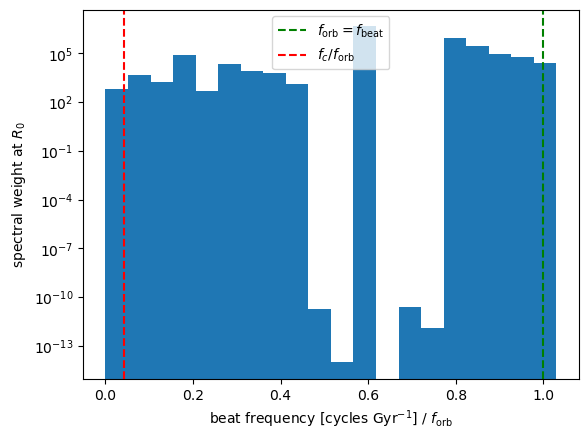

max weight beat period [Gyr]: 0.7155075385871119


In [16]:
mask = f_beat.ravel() > 0
plt.hist(f_beat.ravel()[mask]/f_orb,
         bins=20, weights=weight.ravel()[mask],
         log=True)
plt.axvline(1, color='g', ls='--', label=r'$f_{\rm orb} = f_{\rm beat}$')
plt.axvline(f_c/f_orb,   color='r', ls='--', label=r'$f_c / f_{\rm orb}$')
plt.xlabel(r'beat frequency [cycles Gyr$^{-1}$] / $f_{\rm orb}$')
plt.ylabel(r'spectral weight at $R_0$')
plt.legend()
plt.show()

max_weight_freq = np.where(weight.ravel()[mask] == weight.ravel()[mask].max(), f_beat.ravel()[mask], np.nan)
max_weight_period = 1 / max_weight_freq
print('max weight beat period [Gyr]:', max_weight_period[~np.isnan(max_weight_period)].min())

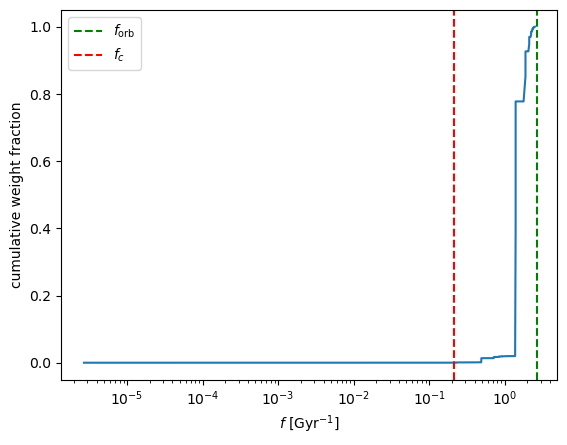

weight fraction with f > 3 f_orb: 0.0


In [5]:
order = np.argsort(f_beat.ravel())
f_sorted = f_beat.ravel()[order]
w_sorted = weight.ravel()[order]
mask = f_sorted > 0
cum = np.cumsum(w_sorted[mask])
cum /= cum[-1]                     # fraction of total weight below f

plt.semilogx(f_sorted[mask], cum)
plt.axvline(f_orb, color='g', ls='--', label=r'$f_{\rm orb}$')
plt.axvline(f_c,   color='r', ls='--', label=r'$f_c$')
plt.xlabel(r'$f$ [Gyr$^{-1}$]'); plt.ylabel('cumulative weight fraction')
plt.legend(); plt.show()

# fraction of weight in the "impulsive" band (above a few × f_orb)
above_3forb = (f_sorted > 3*f_orb)
print('weight fraction with f > 3 f_orb:', w_sorted[above_3forb].sum() / w_sorted.sum())
